# Linear Regression
With Cross-Validation, Seasonality and Hyperparameter Tuning\
Takes user input as a csv file and model is saved 

### 1. Configuration, Loading Dataset 

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

DATA_PATH = r"E:\INCOIS_Internhip\Data\Raw_data.parquet"
MODEL_DIR = r"E:\INCOIS_Internhip\Models"
PLOT_DIR  = r"E:\INCOIS_Internhip\Results\Plots"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

FEATURES = [
    'TEMP(degC)', 'Depth(m)', 'LAT', 'LON',
    'time_days', 'doy_sin', 'doy_cos'
]
TARGET = 'PSAL(psu)'
PROFILE_COL = 'profile_id'

df = pd.read_parquet(DATA_PATH)

X = df[FEATURES]
y = df[TARGET]
profiles = df[PROFILE_COL]

### 2. Spatio-Temporal Blocks

In [ ]:
# Spatial Blocks (2 × 2 = 4)

lat_edges = np.quantile(df['LAT'], [0, 0.5, 1.0])
lon_edges = np.quantile(df['LON'], [0, 0.5, 1.0])

def assign_bins(values, edges):
    return np.digitize(values, edges[1:-1], right=True)

df['lat_bin'] = assign_bins(df['LAT'], lat_edges)
df['lon_bin'] = assign_bins(df['LON'], lon_edges)
df['spatial_block'] = df['lat_bin'] * 2 + df['lon_bin']

# Temporal Blocks (10)

time_edges = np.quantile(df['DATES'].astype('int64'), np.linspace(0,1,11))
df['time_block'] = assign_bins(df['DATES'].astype('int64'), time_edges)

# Cleanup
df.drop(columns=['lat_bin','lon_bin'], inplace=True)

# Sanity check
print("Spatial blocks:", sorted(df['spatial_block'].unique()))
print("Temporal blocks:", sorted(df['time_block'].unique()))

Spatial blocks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Temporal blocks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### 3. Train/Test Split (Profile-wise)

In [3]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, profiles))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

split_info = {
    "train_profiles": df_train["profile_id"].unique().tolist(),
    "test_profiles": df_test["profile_id"].unique().tolist(),
    "split_method": "GroupShuffleSplit(profile_id)",
    "test_size": 0.2,
    "random_state": 42
}

### 4. Spatio-Temporal Cross-Validation

CV loop

In [4]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
cv_scores = {a: [] for a in alphas}

for sb in df_train['spatial_block'].unique():
    for tb in df_train['time_block'].unique():

        mask = (
            (df_train['spatial_block'] == sb) &
            (df_train['time_block'] == tb)
        )

        fold_test = df_train[mask]
        fold_train = df_train[~mask]

        if len(fold_test) == 0:
            continue

        for alpha in alphas:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=alpha))
            ])

            pipe.fit(fold_train[FEATURES], fold_train[TARGET])
            preds = pipe.predict(fold_test[FEATURES])

            rmse = np.sqrt(mean_squared_error(
                fold_test[TARGET], preds
            ))
            cv_scores[alpha].append(rmse)

Best Alpha

In [5]:
mean_rmse = {
    a: np.mean(scores)
    for a, scores in cv_scores.items()
}

best_alpha = min(mean_rmse, key=mean_rmse.get)

print("CV RMSE per alpha:")
for a, rmse in mean_rmse.items():
    print(f"alpha={a:6} | RMSE={rmse:.4f}")

print("Chosen alpha:", best_alpha)

CV RMSE per alpha:
alpha=  0.01 | RMSE=0.2586
alpha=   0.1 | RMSE=0.2586
alpha=   1.0 | RMSE=0.2586
alpha=  10.0 | RMSE=0.2586
alpha= 100.0 | RMSE=0.2586
Chosen alpha: 100.0


### 5. Training

In [6]:
final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

final_pipe.fit(df_train[FEATURES], df_train[TARGET])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",100.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


### 6. Test Set Evaluation

TEST RMSE: 0.2745
TEST MAE : 0.1408
TEST R²  : 0.2976


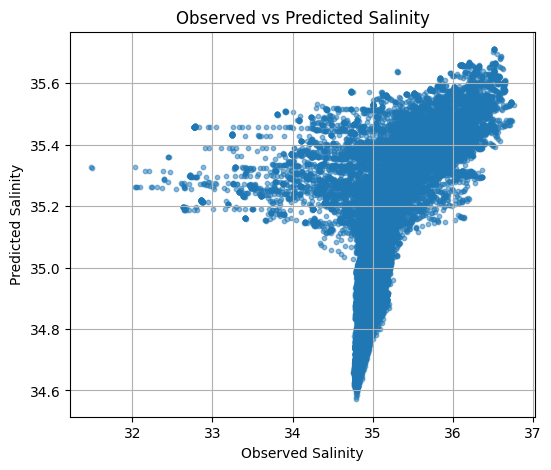

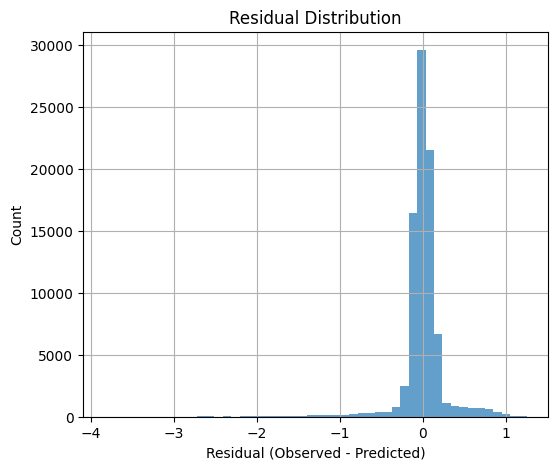

In [7]:
y_test_pred = final_pipe.predict(df_test[FEATURES])

rmse = np.sqrt(mean_squared_error(df_test[TARGET], y_test_pred))
mae  = mean_absolute_error(df_test[TARGET], y_test_pred)
r2   = r2_score(df_test[TARGET], y_test_pred)

print(f"TEST RMSE: {rmse:.4f}")
print(f"TEST MAE : {mae:.4f}")
print(f"TEST R²  : {r2:.4f}")

import matplotlib.pyplot as plt

# Scatter plot (Observed vs Predicted)
plt.figure(figsize=(6,5))
plt.scatter(df_test[TARGET], y_test_pred, s=10, alpha=0.5)
plt.xlabel("Observed Salinity")
plt.ylabel("Predicted Salinity")
plt.title("Observed vs Predicted Salinity")
plt.grid(True)
plt.show()

# Residual distribution
residuals = df_test[TARGET] - y_test_pred

plt.figure(figsize=(6,5))
plt.hist(residuals, bins=50, alpha=0.7)
plt.xlabel("Residual (Observed - Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.grid(True)
plt.show()

### 7. Saving linreg.pkl Model

In [8]:
import os
import joblib

MODEL_DIR = r"E:\INCOIS_Internhip\Models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(
    MODEL_DIR, "linreg.pkl"
)

joblib.dump(
    {
        "pipeline": final_pipe,
        "features": FEATURES,
        "target": TARGET,
        "split_info": split_info
    },
    model_path
)

print("Model saved at:", model_path)
print("Exists?", os.path.exists(model_path))

Model saved at: E:\INCOIS_Internhip\Models\linreg.pkl
Exists? True


# --------------------------------------------------------------------------------------------

### I. Loading Model

In [9]:
import joblib
import pandas as pd

model_path = r"E:\INCOIS_Internhip\Models\linreg.pkl"

bundle = joblib.load(model_path)
pipe = bundle["pipeline"]
features = bundle["features"] # feature order
target = bundle["target"] # target name

### II. Pipeline Structure,  Model Information, Scalers, Features, Coefficients, Split Data 

In [ ]:
import joblib
import pandas as pd
import numpy as np

MODEL_PATH = r"E:\INCOIS_Internhip\Models\linreg.pkl"

# Loading bundle

bundle = joblib.load(MODEL_PATH)

pipe = bundle["pipeline"]
features = bundle["features"]
target = bundle.get("target", "Unknown")
split_info = bundle.get("split_info", None)

print("MODEL OVERVIEW")

# Pipeline structure
print("\nPipeline steps:")
for name, step in pipe.named_steps.items():
    print(f" - {name}: {step.__class__.__name__}")

# Model information
model = pipe.named_steps["model"]

print("\nModel type:", model.__class__.__name__)
print("Model hyperparameters:")
for k, v in model.get_params().items():
    print(f"  {k}: {v}")

# Scaler info
scaler = pipe.named_steps["scaler"]

print("\nScaler type:", scaler.__class__.__name__)
print("Number of features scaled:", scaler.n_features_in_)

scaler_df = pd.DataFrame({
    "Feature": features,
    "Mean": scaler.mean_,
    "Std": scaler.scale_
})
print("\nScaler statistics:")
print(scaler_df)

# Feature list
print("\nFeature list (in order):")
for i, f in enumerate(features):
    print(f" {i+1}. {f}")

# Coefficients
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient (scaled space)": model.coef_
})

print("\nRegression coefficients (scaled space):")
print(coef_df)

print("Intercept:", model.intercept_)

# Train / Test split info
if split_info is not None:
    print("\nDATA SPLIT INFORMATION")

    for k, v in split_info.items():
        if isinstance(v, list):
            print(f"{k}: {len(v)} entries")
        else:
            print(f"{k}: {v}")
else:
    print("\nNo split metadata found.")

MODEL OVERVIEW

Pipeline steps:
 - scaler: StandardScaler
 - model: Ridge

Model type: Ridge
Model hyperparameters:
  alpha: 100.0
  copy_X: True
  fit_intercept: True
  max_iter: None
  positive: False
  random_state: None
  solver: auto
  tol: 0.0001

Scaler type: StandardScaler
Number of features scaled: 7

Scaler statistics:
      Feature         Mean          Std
0  TEMP(degC)    11.930243     6.879184
1    Depth(m)   639.281522   500.828947
2         LAT     7.540754     1.666405
3         LON    73.016951     1.989566
4   time_days  4386.385718  1151.166174
5     doy_sin    -0.129071     0.703455
6     doy_cos    -0.032949     0.698144

Feature list (in order):
 1. TEMP(degC)
 2. Depth(m)
 3. LAT
 4. LON
 5. time_days
 6. doy_sin
 7. doy_cos

Regression coefficients (scaled space):
      Feature  Coefficient (scaled space)
0  TEMP(degC)                    0.080628
1    Depth(m)                   -0.061038
2         LAT                    0.064465
3         LON                   

### III. Sanity Check Plot (over any dataset)

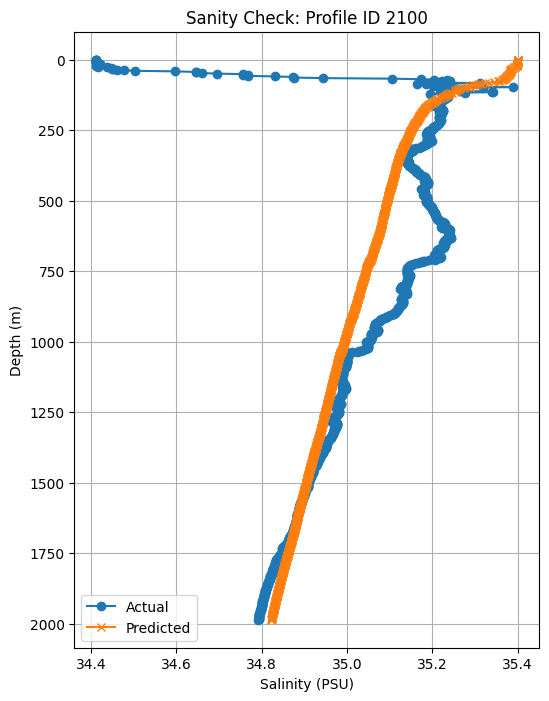

In [37]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading model
bundle = joblib.load(r"E:\INCOIS_Internhip\Models\linreg.pkl")
pipe = bundle["pipeline"]
features = bundle["features"]
target = bundle["target"]

# Loading any dataset with PSAL data
df = pd.read_parquet(r"E:\INCOIS_Internhip\Data\Raw_data.parquet")

# Picking a random profile
random_profile = np.random.choice(df["profile_id"].unique())
mask = df["profile_id"] == random_profile

X_profile = df.loc[mask, features]
y_profile = df.loc[mask, target]
depths = df.loc[mask, "Depth(m)"]

# Prediction
y_pred = pipe.predict(X_profile)

# Sorting by depth
idx = np.argsort(depths.values)

depths_sorted = depths.iloc[idx]
y_actual_sorted = y_profile.iloc[idx]
y_pred_sorted = y_pred[idx]

# Plot
plt.figure(figsize=(6, 8))
plt.plot(y_actual_sorted, depths_sorted, label="Actual", marker="o")
plt.plot(y_pred_sorted, depths_sorted, label="Predicted", marker="x")
plt.gca().invert_yaxis()
plt.xlabel("Salinity (PSU)")
plt.ylabel("Depth (m)")
plt.title(f"Sanity Check: Profile ID {random_profile}")
plt.legend()
plt.grid(True)
plt.show()

# Prediction from User Input

1: Load the saved model

In [12]:
import joblib
import os

# Load pipeline
bundle = joblib.load(r"E:\INCOIS_Internhip\Models\linreg.pkl")
pipe = bundle["pipeline"]
features = bundle["features"]   # list of features used during training
target = bundle["target"]       # optional, just for reference

2: Upload user data file

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

def predict_salinity(file_path, model_path, plot_profile=True, save_output=True, output_path=None):

    # 1️. Load user file (CSV)
    df_new = pd.read_csv(file_path)

    # 2️. Feature engineering
    df_new['DATES'] = pd.to_datetime(df_new['DATES'])

    ref_date = pd.Timestamp("2005-01-01")
    df_new['time_days'] = (df_new['DATES'] - ref_date).dt.total_seconds() / (24*3600)

    df_new['doy'] = df_new['DATES'].dt.dayofyear
    df_new['doy_sin'] = np.sin(2 * np.pi * df_new['doy'] / 365.25)
    df_new['doy_cos'] = np.cos(2 * np.pi * df_new['doy'] / 365.25)

    # 3️. Loading model
    bundle = joblib.load(model_path)
    pipe = bundle["pipeline"]
    features = bundle["features"]
    target = bundle.get("target", None)

    # 4️. Prediction
    df_new['Predicted_PSAL'] = pipe.predict(df_new[features])

    # 5. Saving output
    if save_output:
        if output_path is None:
            base, ext = os.path.splitext(file_path)
            output_path = f"{base}_with_predictions.csv"

        df_new.to_csv(output_path, index=False)
        print(f"Predictions saved to:\n{output_path}")

    return df_new

# Uploading user data
print("The input CSV must contain the following columns, in any order, with exact names:")
print(['TEMP(degC)', 'Depth(m)', 'LAT', 'LON', 'DATES'])

file_path = input("Enter path to input CSV file: ").strip().strip('"').strip("'")

df_pred = predict_salinity(
    file_path=file_path,
    model_path=r"E:\INCOIS_Internhip\Models\linreg.pkl",
    plot_profile=True,
    save_output=True
)

print(df_pred.head())

The input CSV must contain the following columns, in any order, with exact names:
['TEMP(degC)', 'Depth(m)', 'LAT', 'LON', 'DATES']


FileNotFoundError: [Errno 2] No such file or directory: ''